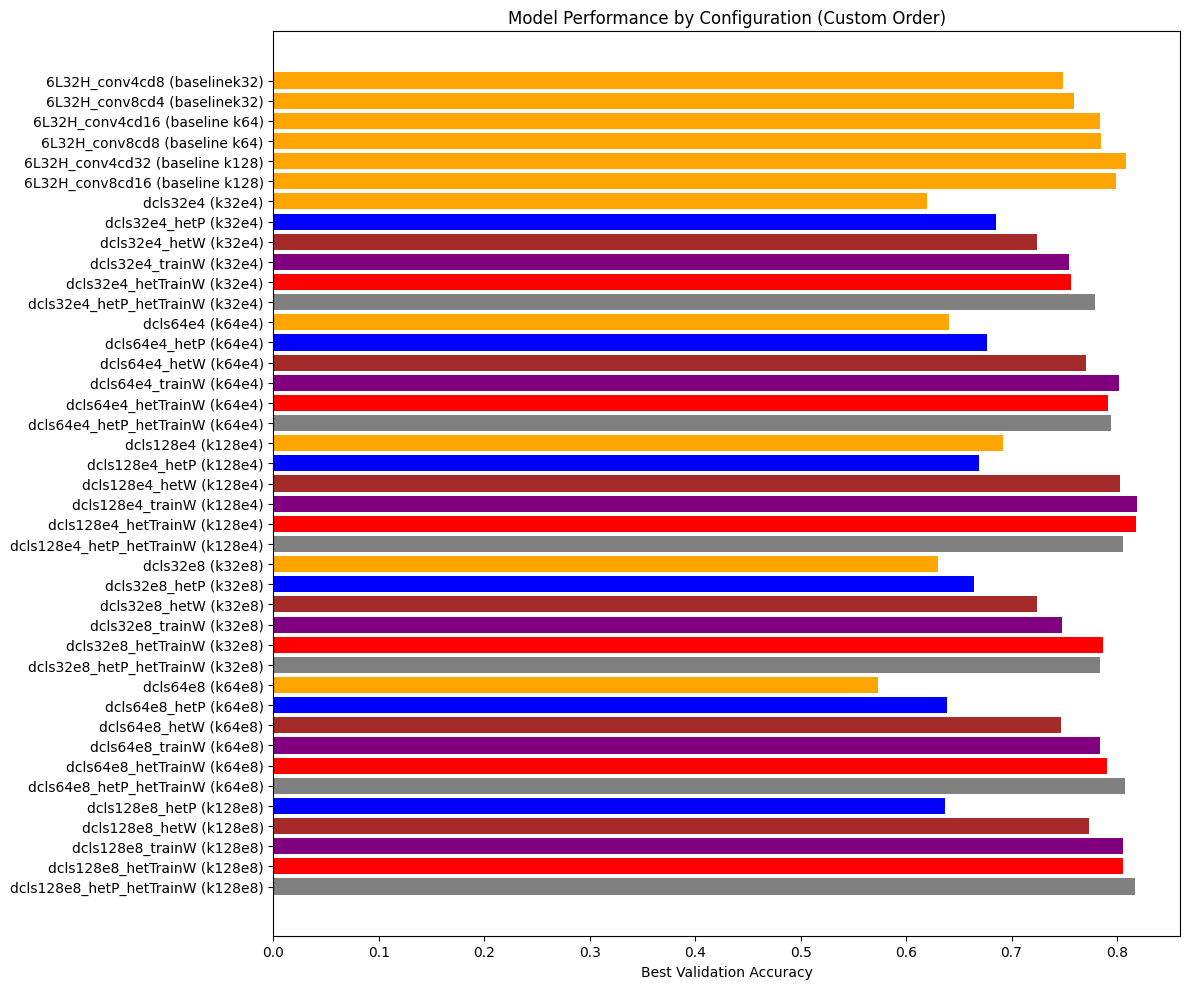

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv('plot.csv')  # Replace with your path if needed

# Assign colors based on type
def assign_color(name):
    if "_hetP_hetTrainW" in name:
        return "grey"
    elif "hetTrainW" in name:
        return "red"
    elif "trainW" in name:
        return "purple"
    elif "hetW" in name:
        return "brown"
    elif "hetP" in name:
        return "blue"
    else:
        return "orange"

df["color"] = df["Name"].apply(assign_color)

# Define desired orderings
key_order = ["k128e8", "k64e8", "k32e8", "k128e4", "k64e4", "k32e4"]
type_order = ["_hetP_hetTrainW", "hetTrainW", "trainW", "hetW", "hetP"]

# Extract key and type from name
def extract_key_type(name):
    key = name.split('(')[-1].strip(')') if '(' in name else ''
    for t in type_order:
        if t in name:
            return key, t
    return key, 'other'

df[['key', 'type']] = df['Name'].apply(lambda n: pd.Series(extract_key_type(n)))

# Assign sort index based on ordering
df['sort_index'] = df.apply(
    lambda row: (key_order.index(row['key']) if row['key'] in key_order else 999,
                 type_order.index(row['type']) if row['type'] in type_order else 999),
    axis=1
)

# Sort the dataframe
df_sorted = df.sort_values(by='sort_index')

# Plotting
plt.figure(figsize=(12, 10))
plt.barh(df_sorted["Name"], df_sorted["best_val_acc"], color=df_sorted["color"])
plt.xlabel("Best Validation Accuracy")
plt.title("Model Performance by Configuration (Custom Order)")
plt.tight_layout()
plt.show()


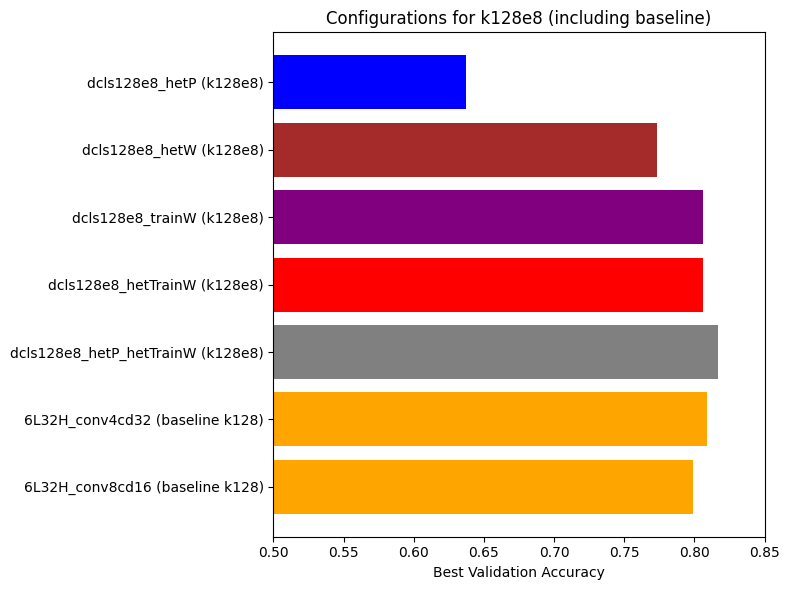

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv('plot.csv')  # Update the path if needed

# Assign colors
def assign_color(name):
    if "_hetP_hetTrainW" in name:
        return "grey"
    elif "hetTrainW" in name:
        return "red"
    elif "trainW" in name:
        return "purple"
    elif "hetW" in name:
        return "brown"
    elif "hetP" in name:
        return "blue"
    else:
        return "orange"

df["color"] = df["Name"].apply(assign_color)

# Set the key to focus on
target_key = "k128e8"  # Change this to k64e8, k32e8, etc.

# Filter for matching rows
focus_df = df[df["Name"].str.contains(f"{target_key}") | df["Name"].str.contains(f"baseline {target_key[:-2]}")].copy()

# Sort by predefined type order
type_order = ["_hetP_hetTrainW", "hetTrainW", "trainW", "hetW", "hetP"]
def extract_type(name):
    for t in type_order:
        if t in name:
            return t
    if "baseline" in name:
        return "baseline"
    return "other"

focus_df["type"] = focus_df["Name"].apply(extract_type)
focus_df["sort_index"] = focus_df["type"].apply(
    lambda t: type_order.index(t) if t in type_order else (999 if t == "other" else -1)
)

# Sort rows
focus_df = focus_df.sort_values(by="sort_index")

# Plot
plt.figure(figsize=(8, 6))
plt.barh(focus_df["Name"], focus_df["best_val_acc"], color=focus_df["color"])
plt.xlabel("Best Validation Accuracy")
plt.title(f"Configurations for {target_key} (including baseline)")
# set x-axis limits
plt.xlim(0.5, 0.85)  # Adjust as needed
plt.tight_layout()
plt.show()


0.759314894676209
-0.11
0.7836538553237915
-0.11
0.7867588400840759
-0.11
0.7477964758872986
-0.11
0.7244591116905212
-0.11
0.6644631624221802
-0.11
0.6300080418586731
-0.11


/tmp/ipykernel_2285581/219855762.py:33: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  focus_df = focus_df[df["Name"].str.contains(f"conv{target_key[-1]}") | focus_df["Name"].str.contains(target_key)]


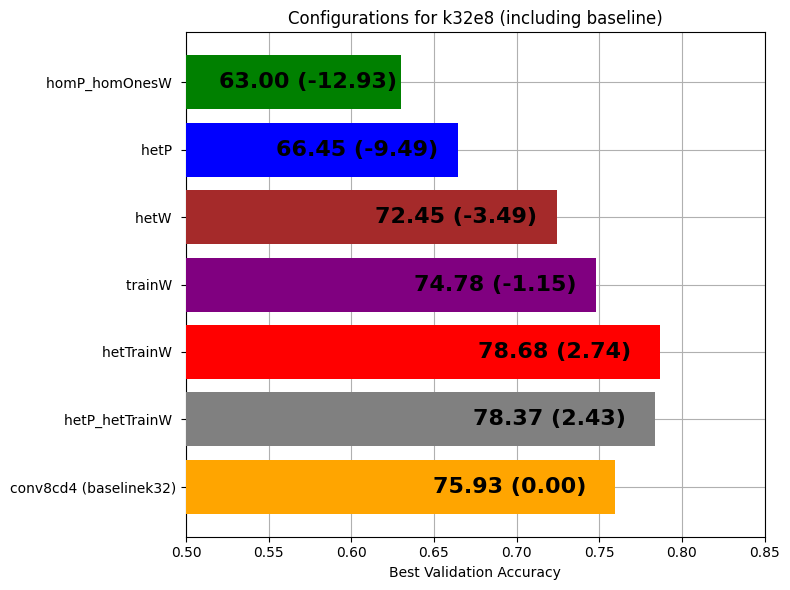

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# Set the key to focus on
target_key = "k32e8"  # Change this as needed

# Load CSV
df = pd.read_csv('plot.csv')  # Update path if needed


# Assign colors
def assign_color(name):
    if "_hetP_hetTrainW" in name:
        return "grey"
    elif "hetTrainW" in name:
        return "red"
    elif "trainW" in name:
        return "purple"
    elif "hetW" in name:
        return "brown"
    elif "hetP" in name:
        return "blue"
    elif "conv" in name:
        return "orange"
    else:
        return "green"

df["color"] = df["Name"].apply(assign_color)


# Filter relevant rows
focus_df = df[df["Name"].str.contains(f"{target_key}") | df["Name"].str.contains(f"baseline {target_key[:-2]}") | df["Name"].str.contains(f"baseline{target_key[:-2]}")].copy()
focus_df = focus_df[df["Name"].str.contains(f"conv{target_key[-1]}") | focus_df["Name"].str.contains(target_key)]

focus_df["Name"] = focus_df["Name"].str.replace(f"dcls{target_key[1:]}_", "", regex=False)
focus_df["Name"] = focus_df["Name"].str.replace(f"dcls{target_key[1:]}", "homP_homOnesW", regex=False)
focus_df["Name"] = focus_df["Name"].str.replace(f"({target_key})", "", regex=False)
focus_df["Name"] = focus_df["Name"].str.replace(f"6L32H_", "", regex=False)


# Define ordering
type_order = ["_hetP_hetTrainW", "hetTrainW", "trainW", "hetW", "hetP"]
def extract_type(name):
    for t in type_order:
        if t in name:
            return t
    if "baseline" in name:
        return "baseline"
    return "other"

focus_df["type"] = focus_df["Name"].apply(extract_type)
focus_df["sort_index"] = focus_df["type"].apply(
    lambda t: type_order.index(t) if t in type_order else (999 if t == "other" else -1)
)

# Sort by type
focus_df = focus_df.sort_values(by="sort_index")

# Plotting
plt.figure(figsize=(8, 6))

bars = plt.barh(focus_df["Name"], focus_df["best_val_acc"], color=focus_df["color"], zorder=3)
plt.xlabel("Best Validation Accuracy")
plt.title(f"Configurations for {target_key} (including baseline)")

baseline = bars[0].get_width() * 100  # Get width of the baseline bar
# Add value labels
for bar in bars:
    print(bar.get_width())
    width = bar.get_width() * 100
    text_offset = - 0.11 if width > 60 else 0.-0.05
    print(text_offset)
    plt.text(width*0.01 + text_offset, bar.get_y() + bar.get_height() / 2,
             f"{width:.2f} ({width-baseline:.2f})", va='center', fontsize=16, fontdict={'weight': 'bold'})

# set x-axis limits
plt.xlim(0.5, 0.85)  # Adjust as needed
plt.grid(zorder=0)
plt.tight_layout()
plt.show()
